# <center>FIFA WORLD CUP 2022 Machine learning Model</center>

**Analyzing the Available Data**

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import random
from IPython.display import Image
random_num=122

# Reading the dataset

In [138]:
df=pd.read_csv("/Users/skmirajulislam/Documents/MyPython/ML/Topstack/data/results.csv")
df.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False


In [139]:
df.describe()

,home_score,away_score
count,44762.000000,44762.000000
mean,1.739176,1.178343
std,1.746801,1.393183
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [140]:
df.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

# finding outliers in the numerical data columns

([<matplotlib.axis.XTick at 0x159559050>,
 [Text(1, 0, 'Home Score'), Text(2, 0, 'Away Score')])

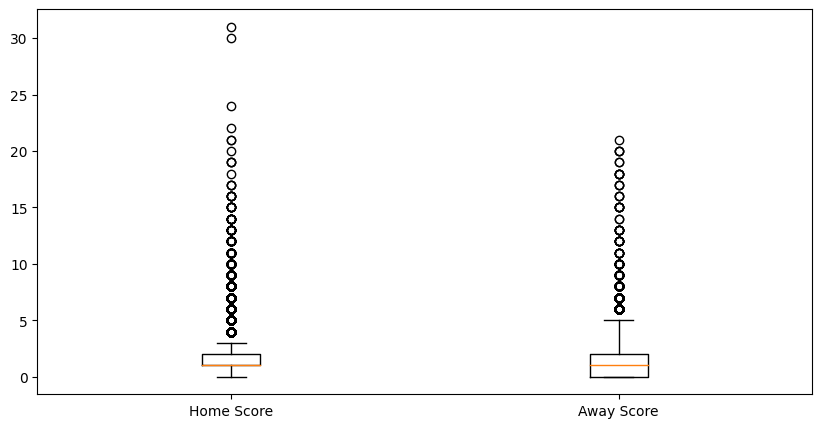

In [141]:
#finding outliers in the numerical data columns

fig = plt.figure(figsize =(10, 5))
plt.boxplot([df["home_score"],df["away_score"]])
plt.xticks([1,2], ["Home Score", "Away Score"])

**Boxplot says there are many outliers**
**Let's remove those outlier,It will make our Machine Learning model more accurate**
**Asume maximum goals that one team can score is 15**

In [142]:
higher_home=15
higher_away=15
print('Dataset after removing outliers')
df=df[(df["home_score"]<higher_home) & (df["away_score"]<higher_away)]
df.head(5)

Dataset after removing outliers


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


Making a new colum named "Win_Statues" to store the result(Win,Lost,Draw) of the home team

In [143]:
conditions  = [df["home_score"] ==df["away_score"], df["home_score"] > df["away_score"] , df["home_score"] < df["away_score"]]
choices     = [ "Draw", 'Win', 'Lost' ]
df["Win_Statues"] = np.select(conditions, choices)
df.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Win_Statues
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,Win
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Win
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,Draw
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Win


See what are the Countries in the dataset

In [144]:
countries=df.home_team.unique()
print(f"There are {len(countries)} Countries in the home_team Column\n")
print(f"Countries-{countries}")

There are 309 Countries in the home_team Column

Countries-['Scotland' 'England' 'Wales' 'Northern Ireland' 'United States' 'Uruguay'
 'Austria' 'Hungary' 'Argentina' 'Belgium' 'France' 'Netherlands'
 'Czechoslovakia' 'Switzerland' 'Sweden' 'Germany' 'Italy' 'Chile'
 'Norway' 'Finland' 'Luxembourg' 'Russia' 'Denmark' 'Catalonia'
 'Basque Country' 'Brazil' 'Paraguay' 'Japan' 'Canada' 'Estonia'
 'Costa Rica' 'Guatemala' 'Spain' 'Brittany' 'Poland' 'Yugoslavia'
 'New Zealand' 'Romania' 'Latvia' 'Galicia' 'Portugal' 'Andalusia'
 'China PR' 'Australia' 'Lithuania' 'Turkey' 'Central Spain' 'Mexico'
 'Aruba' 'Egypt' 'Haiti' 'Philippines' 'Bulgaria' 'Jamaica' 'Kenya'
 'Bolivia' 'Peru' 'Honduras' 'Guyana' 'Uganda' 'Belarus' 'El Salvador'
 'Barbados' 'Republic of Ireland' 'Trinidad and Tobago' 'Greece' 'Curaçao'
 'Dominica' 'Silesia' 'Guadeloupe' 'Israel' 'Suriname' 'French Guiana'
 'Cuba' 'Colombia' 'Ecuador' 'Saint Kitts and Nevis' 'Panama' 'Slovakia'
 'Manchukuo' 'Croatia' 'Nicaragua' 'Afghan

**Type of the Matches**

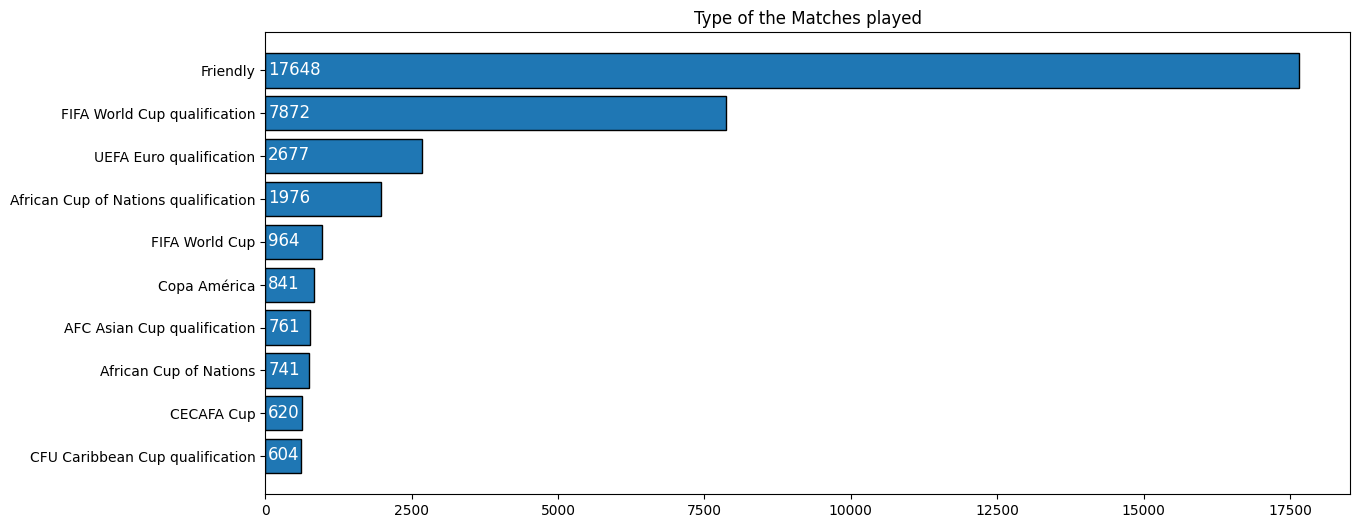

In [145]:
rank_bound = 10
ax = df.tournament.value_counts()[:rank_bound].sort_values()
value = ax.values
label = ax.index

plt.figure(figsize=(14,6))
plt.barh(y=label, width=value, edgecolor="k")
plt.title('Type of the Matches played')
for i in range(rank_bound):
    plt.text(x=50,y=i-0.1,s=value[i],color="w",fontsize=12)
plt.show()

**Teams played most Matches**

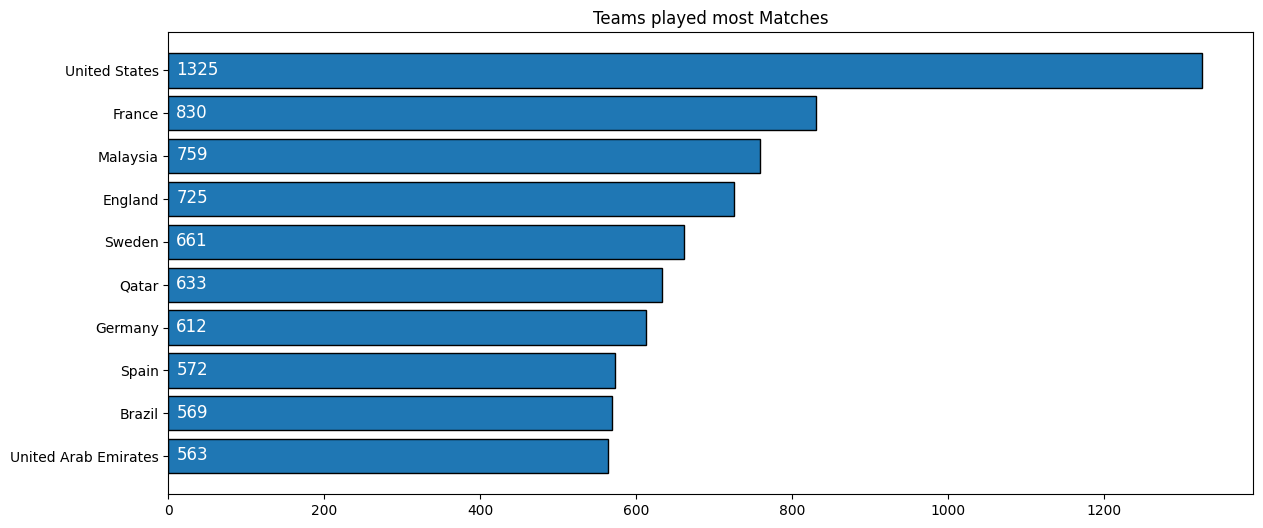

In [146]:
rank_bound = 10
ax = df.country.value_counts()[:rank_bound].sort_values()
value = ax.values
label = ax.index

plt.figure(figsize=(14,6))
plt.barh(y=label, width=value, edgecolor="k")
plt.title('Teams played most Matches')
for i in range(rank_bound):
    plt.text(x=10,y=i-0.1,s=value[i],color="w",fontsize=12)
plt.show()

**Number of Matches played in equal intervals**

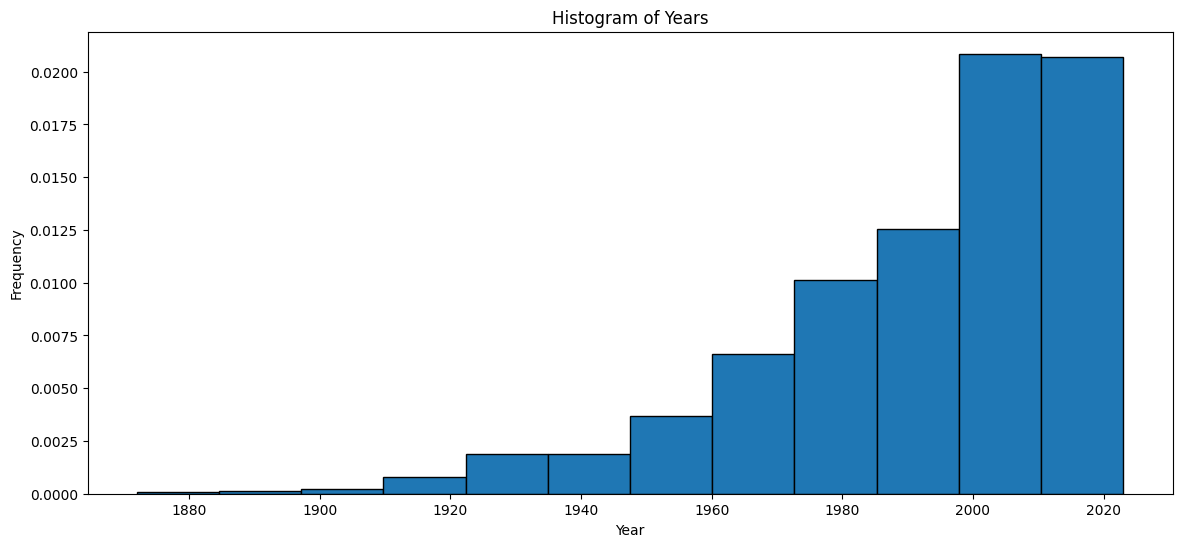

In [147]:
years = []
for date in df.date:
    years.append(int(str(date)[0:4]))
plt.figure(figsize=(14,6))
plt.hist(years, density=True, bins=12, edgecolor="k")
plt.title("Histogram of Years")
plt.ylabel("Frequency")
plt.xlabel("Year")
plt.show()

**(1) Finding out the impact hosting a major tournament helps a country's chances in winning matches?**

In [148]:
data_home=df.loc[df["home_team"]==df["country"] ]
data_home=df.loc[df["tournament"] != "Friendly"]
data_home.head(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Win_Statues
29,1884-01-26,Northern Ireland,Scotland,0,5,British Home Championship,Belfast,Ireland,False,Lost
30,1884-02-09,Wales,Northern Ireland,6,0,British Home Championship,Wrexham,Wales,False,Win
31,1884-02-23,Northern Ireland,England,1,8,British Home Championship,Belfast,Ireland,False,Lost
32,1884-03-15,Scotland,England,1,0,British Home Championship,Glasgow,Scotland,False,Win
33,1884-03-17,Wales,England,0,4,British Home Championship,Wrexham,Wales,False,Lost


# Home Team Winning Statistcs

In [149]:
#How home team performs in tournament matches
tournament_df=pd.crosstab(data_home["tournament"], data_home["Win_Statues"],margins=True)
tournament_df=tournament_df.sort_values("All",ascending=False).head(10)
tournament_df.style.bar(color="brown",subset=["Draw","Lost","Win","All"])

Win_Statues,Draw,Lost,Win,All
tournament,,,,
All,5873,7750,13440,27063
FIFA World Cup qualification,1653,2184,4035,7872
UEFA Euro qualification,523,850,1304,2677
African Cup of Nations qualification,481,397,1098,1976
FIFA World Cup,214,311,439,964
Copa América,181,230,430,841
AFC Asian Cup qualification,126,188,447,761
African Cup of Nations,209,200,332,741
CECAFA Cup,147,185,288,620


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 1.0, 'Home Team Winning Status')

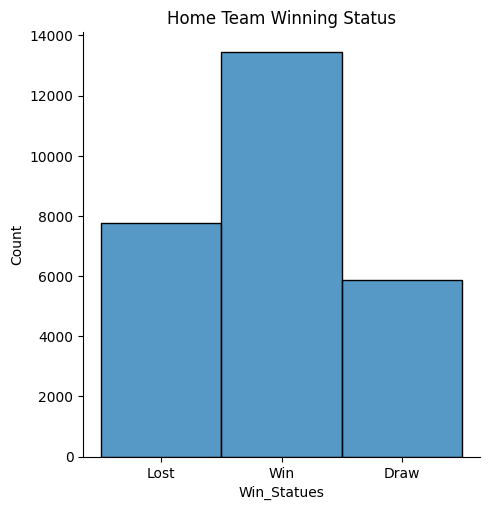

In [150]:
#Home team results
sns.displot(data_home, x="Win_Statues")
plt.title("Home Team Winning Status")

In [151]:
data_home['Win_Statues'].value_counts()

Win_Statues
Win     13440
Lost     7750
Draw     5873
Name: count, dtype: int64

In [152]:
#How each team perform while playing a tournament in home grounds
teams_win_statues=pd.crosstab(df["home_team"], df["Win_Statues"],margins=True, margins_name="Total")
teams_win_statues["team_win_probability"]=teams_win_statues["Win"]/(teams_win_statues["Total"])

#Lets take teams which plays atleast 200 games
teams_win_statues_100=teams_win_statues.loc[teams_win_statues["Total"]>200]
teams_win_statues_100=teams_win_statues_100.sort_values("team_win_probability",ascending=False)
teams_win_statues_100.head(20).style.bar(color="orange",subset="team_win_probability")

#We can see teams has more than 50% wining probability while playing in the home grounds 

Win_Statues,Draw,Lost,Win,Total,team_win_probability
home_team,,,,,
Brazil,110,59,428,597,0.716918
Spain,71,51,259,381,0.679790
Argentina,125,69,383,577,0.663778
Egypt,70,74,262,406,0.645320
Ivory Coast,67,36,184,287,0.641115
Nigeria,69,37,185,291,0.635739
Iran,64,45,187,296,0.631757
Italy,123,53,291,467,0.623126
England,115,84,328,527,0.622391


# Away team winning statistics

In [153]:
#Teams playing in away conditions

teams_away_statues=pd.crosstab(df["away_team"], df["Win_Statues"],margins=True, margins_name="Total")
teams_away_statues["team_win_probability"]=teams_away_statues["Lost"]/(teams_away_statues["Total"])
#Lets take teams which plays atleast 200 games
teams_away_statues_100=teams_away_statues.loc[teams_away_statues["Total"]>200]
teams_away_statues_100=teams_away_statues_100.sort_values("team_win_probability",ascending=False)
teams_away_statues_100.rename(columns={'Lost': 'Win'}, index={'Win': 'Lost'}, inplace=True)
teams_away_statues_100.head(20)

#The probability to wining a tournament in away conditions is very low comapred to the winning probalities in home conditions

Win_Statues,Draw,Win,Win,Total,team_win_probability
away_team,,,,,
Germany,94,247,120,461,0.535792
Brazil,96,229,104,429,0.533800
England,136,273,117,526,0.519011
Spain,102,169,85,356,0.474719
Iran,67,107,58,232,0.461207
South Korea,115,181,110,406,0.445813
Netherlands,83,169,130,382,0.442408
Russia,119,176,113,408,0.431373
Japan,57,117,103,277,0.422383


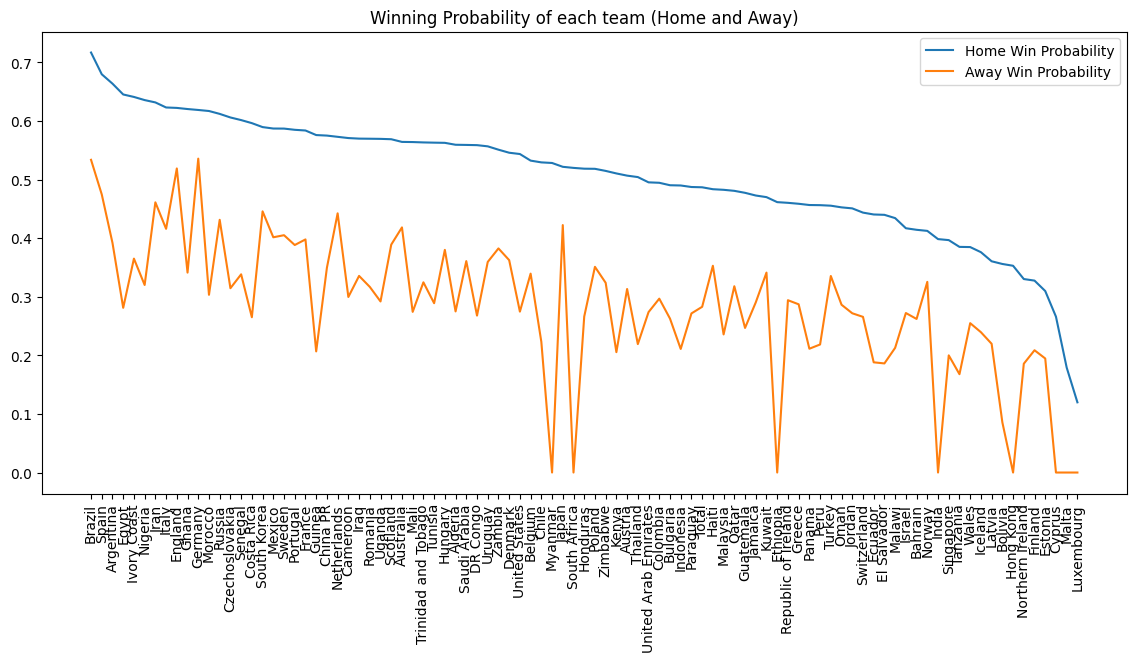

In [154]:
#Making a plot to identify wining possibilities in both home and away conditions

win_prob={teams_win_statues_100.iloc[i,:].name:[teams_win_statues_100.iloc[i,4]] for i in range(teams_win_statues_100.shape[0])}
for i in range(teams_away_statues_100.shape[0]):
    try:
        win_prob[teams_away_statues_100.iloc[i,:].name].append(teams_away_statues_100.iloc[i,4]) 
    except:
        pass
country_names=win_prob.keys()
lst_home=[i[0] for i in win_prob.values()]

lst_away=[]
for i in win_prob.values():
    if len(i)==2:
        lst_away.append(i[1])
    else:
        lst_away.append(0)

plt.figure(figsize=(14,6))
plt.plot(country_names,lst_home, label = "Home Win Probability")
plt.plot(country_names, lst_away, label = "Away Win Probability")
plt.xticks(rotation = 90)
plt.title("Winning Probability of each team (Home and Away)")
plt.legend()
plt.show()

**Blue line is alway above the yellow line,showing home winning possibilies are always higher.**

Finally by analysing the data, we can identify that the home team has a clear edge while playing a tournament in their home grounds

In [155]:
# ! pip3 install tabulate

# (3) FIFA World Cup -2022- QATAR

**Making a ML model**

In [156]:
df_match=df.copy() #making a copy of the main dataframe for future use
df_match.head(8)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Win_Statues
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,Draw
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,Win
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,Win
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,Draw
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,Win
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False,Win
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,Lost
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False,Lost


In [157]:
#Making a new dataset with required features to train the machine learning model
#Year,Played Country,Team_1,team_2,team_1 score,team_2 score
New_Dataset_part_1 = pd.DataFrame(list(zip(years,df_match.values[:,7],df_match.values[:,1],df_match.values[:,2],df_match.values[:,3],df_match.values[:,4])),columns=["year","Country","team_1","team_2","team_1_score","team_2_score"])

#Making a new dataset by changing the team_1 and team_2 and their respective scores
New_Dataset_part_2 = pd.DataFrame(list(zip(years,df_match.values[:,7],df_match.values[:,2],df_match.values[:,1],df_match.values[:,4],df_match.values[:,3])),columns=["year","Country","team_1","team_2","team_1_score","team_2_score"])

New_Dataset = pd.concat([New_Dataset_part_1,New_Dataset_part_2],axis=0)
New_Dataset = New_Dataset.sample(frac=1).reset_index(drop=True) #Shaffling the dataset
New_Dataset.head(5)

,year,Country,team_1,team_2,team_1_score,team_2_score
0,2007,Venezuela,United States,Argentina,1,4
1,1979,Northern Ireland,Northern Ireland,England,0,2
2,2002,Samoa,Papua New Guinea,Tonga,5,0
3,1996,Italy,Italy,Belgium,2,2
4,1995,Uruguay,Argentina,Bolivia,2,1


In [158]:
#Creating a list containg all the names of the countries

teams_1=New_Dataset.team_1.unique()
contries=New_Dataset.Country.unique()
all_countries=np.unique(np.concatenate((teams_1,contries), axis=0))
len(all_countries)

350

,year,team_1_score,team_2_score
year,1.000000,-0.124663,-0.124663
team_1_score,-0.124663,1.000000,-0.163004
team_2_score,-0.124663,-0.163004,1.000000


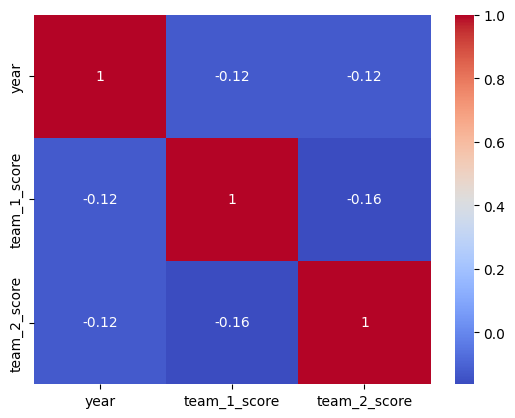

In [159]:
non_numeric_columns = New_Dataset.select_dtypes(exclude=['float64', 'int64']).columns
New_Dataset_corr = New_Dataset.drop(columns=non_numeric_columns)

correlation_matrix = New_Dataset_corr.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
correlation_matrix

In [160]:
New_Dataset

,year,Country,team_1,team_2,team_1_score,team_2_score
0,2007,Venezuela,United States,Argentina,1,4
1,1979,Northern Ireland,Northern Ireland,England,0,2
2,2002,Samoa,Papua New Guinea,Tonga,5,0
3,1996,Italy,Italy,Belgium,2,2
4,1995,Uruguay,Argentina,Bolivia,2,1
...,...,...,...,...,...,...
89417,2015,Ethiopia,Malawi,Djibouti,3,0
89418,2021,Latvia,Norway,Latvia,2,0
89419,1995,Japan,Scotland,Ecuador,2,1
89420,2001,Martinique,Martinique,British Virgin Islands,6,0


In [161]:
#Defining the features and labels(Targets)

Y= New_Dataset.iloc[:,4:6] #Training targets (team_1_score and team_2_score)
categorized_data=New_Dataset.iloc[:,0:4].copy() #Traing features

from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

#Labeling the data using LabelEncorder in Sklearn-(Giving a unique number to each string(country))

label_encoder.fit(all_countries)
#list(label_encoder.classes_)
categorized_data['team_1']=label_encoder.transform(categorized_data['team_1'])
categorized_data['team_2']=label_encoder.transform(categorized_data['team_2'])
categorized_data['Country']=label_encoder.transform(categorized_data['Country'])

#Converting these feature columns to categrize form to make the training processs more smoother
categorized_data['team_1']=categorized_data['team_1'].astype("category")
categorized_data['team_2']=categorized_data['team_2'].astype("category")
categorized_data['Country']=categorized_data['team_2'].astype("category")

In [162]:
categorized_data.head(5)

,year,Country,team_1,team_2
0,2007,12,319,12
1,1979,92,217,92
2,2002,306,231,306
3,1996,29,146,29
4,1995,37,12,37


In [163]:
Y.head(5)

,team_1_score,team_2_score
0,1,4
1,0,2
2,5,0
3,2,2
4,2,1


In [164]:
print(categorized_data.info())
print(Y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89422 entries, 0 to 89421
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   year     89422 non-null  int64   
 1   Country  89422 non-null  category
 2   team_1   89422 non-null  category
 3   team_2   89422 non-null  category
dtypes: category(3), int64(1)
memory usage: 1.2 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89422 entries, 0 to 89421
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   team_1_score  89422 non-null  int64
 1   team_2_score  89422 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB
None


In [165]:
X=categorized_data
from sklearn.multioutput import MultiOutputRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Use any algorithm

 is like linear regression, but with more than one independent value, meaning that we try to predict a value based on two or more variables.

In [166]:
model = MultiOutputRegressor(RandomForestClassifier())
model.fit(X,Y)
prd=model.predict(X)
prd

array([[1, 4],
       [0, 4],
       [5, 0],
       ...,
       [2, 1],
       [6, 0],
       [1, 1]])

In [167]:

print('MultiOutputRegressor Accuracy: ',model.score(X,Y)*100)

MultiOutputRegressor Accuracy:  73.97056998352141


In [168]:
model2 = MultiOutputRegressor(DecisionTreeClassifier())
model2.fit(X,Y)
print('DecisionTreeClassifier Neighbors Accuracy : ',model2.score(X,Y)*100)

DecisionTreeClassifier Neighbors Accuracy :  73.43487268387719


In [169]:
score_team_1=[i[0] for i in prd]
score_team_2=[i[1] for i in prd]

from sklearn.metrics import confusion_matrix
cm1=confusion_matrix(list(Y.iloc[:,0]),score_team_1)
cm2=confusion_matrix(list(Y.iloc[:,1]),score_team_2)

**Dia gonal Element Represent The number of points for which The predicted label is equal to the true label**

 while off-diagonal elements are those that are mislabeled by the classifier. The higher the diagonal values of the confusion matrix the better, indicating many correct predictions. 

Text(220.72222222222223, 0.5, 'Predicted')

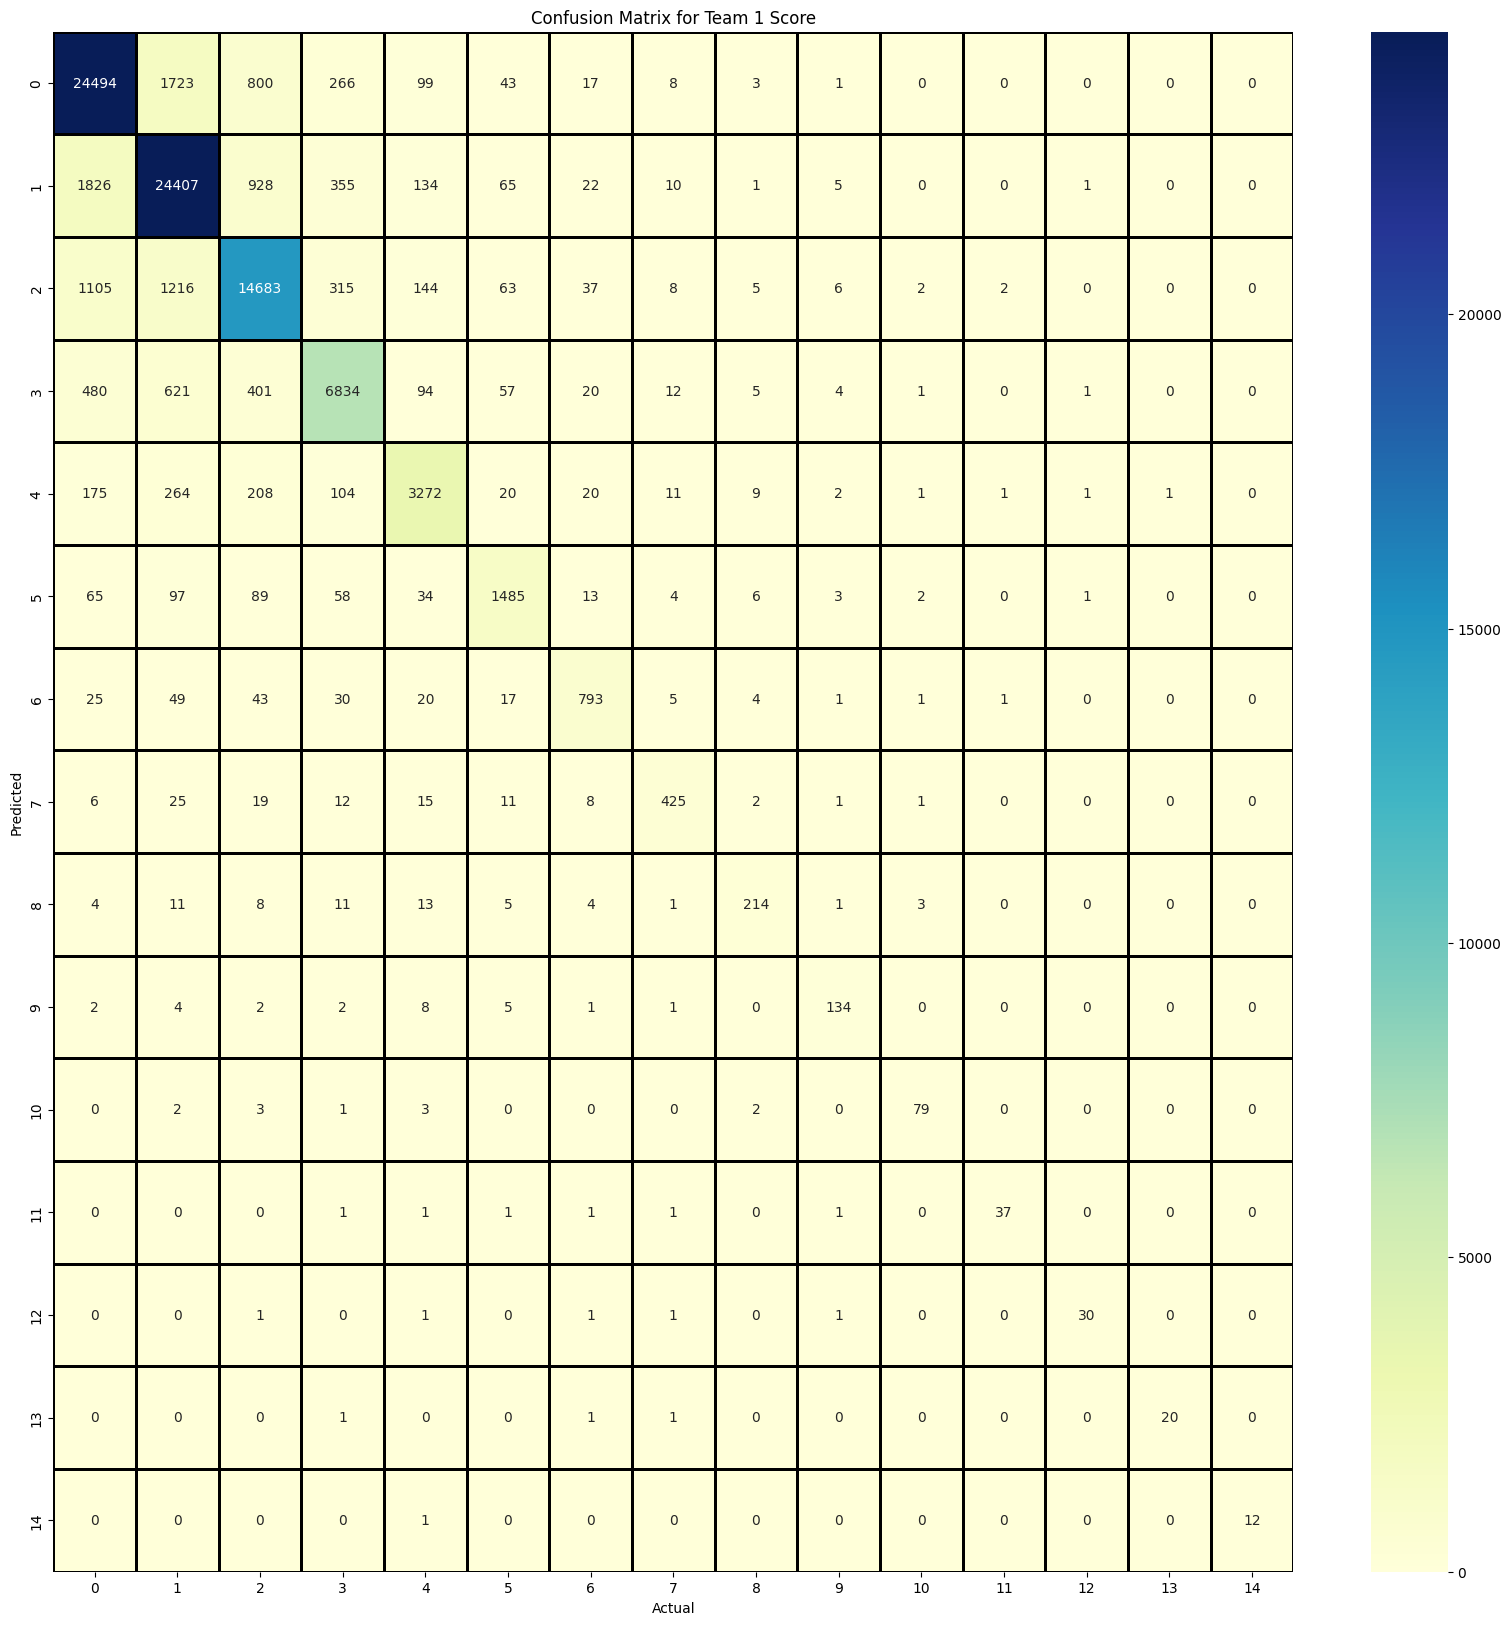

In [170]:
#Plotting the Confussion Matrix for score of team 01
plt.figure(figsize=(20,20))
sns.heatmap(cm1, annot=True,fmt="d", cmap='YlGnBu', linecolor='black', linewidths=1)
plt.title("Confusion Matrix for Team 1 Score")
plt.xlabel("Actual")
plt.ylabel("Predicted")

To generate a classification report for a classification task

In [171]:
from sklearn.metrics import classification_report
report_1=classification_report(Y.iloc[:,0],score_team_1)
print(report_1)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     27454
           1       0.86      0.88      0.87     27754
           2       0.85      0.83      0.84     17586
           3       0.86      0.80      0.83      8530
           4       0.85      0.80      0.83      4089
           5       0.84      0.80      0.82      1857
           6       0.85      0.80      0.82       989
           7       0.87      0.81      0.84       525
           8       0.85      0.78      0.81       275
           9       0.84      0.84      0.84       159
          10       0.88      0.88      0.88        90
          11       0.90      0.86      0.88        43
          12       0.88      0.86      0.87        35
          13       0.95      0.87      0.91        23
          14       1.00      0.92      0.96        13

    accuracy                           0.86     89422
   macro avg       0.88      0.84      0.86     89422
weighted avg       0.86   

Text(220.72222222222223, 0.5, 'Predicted')

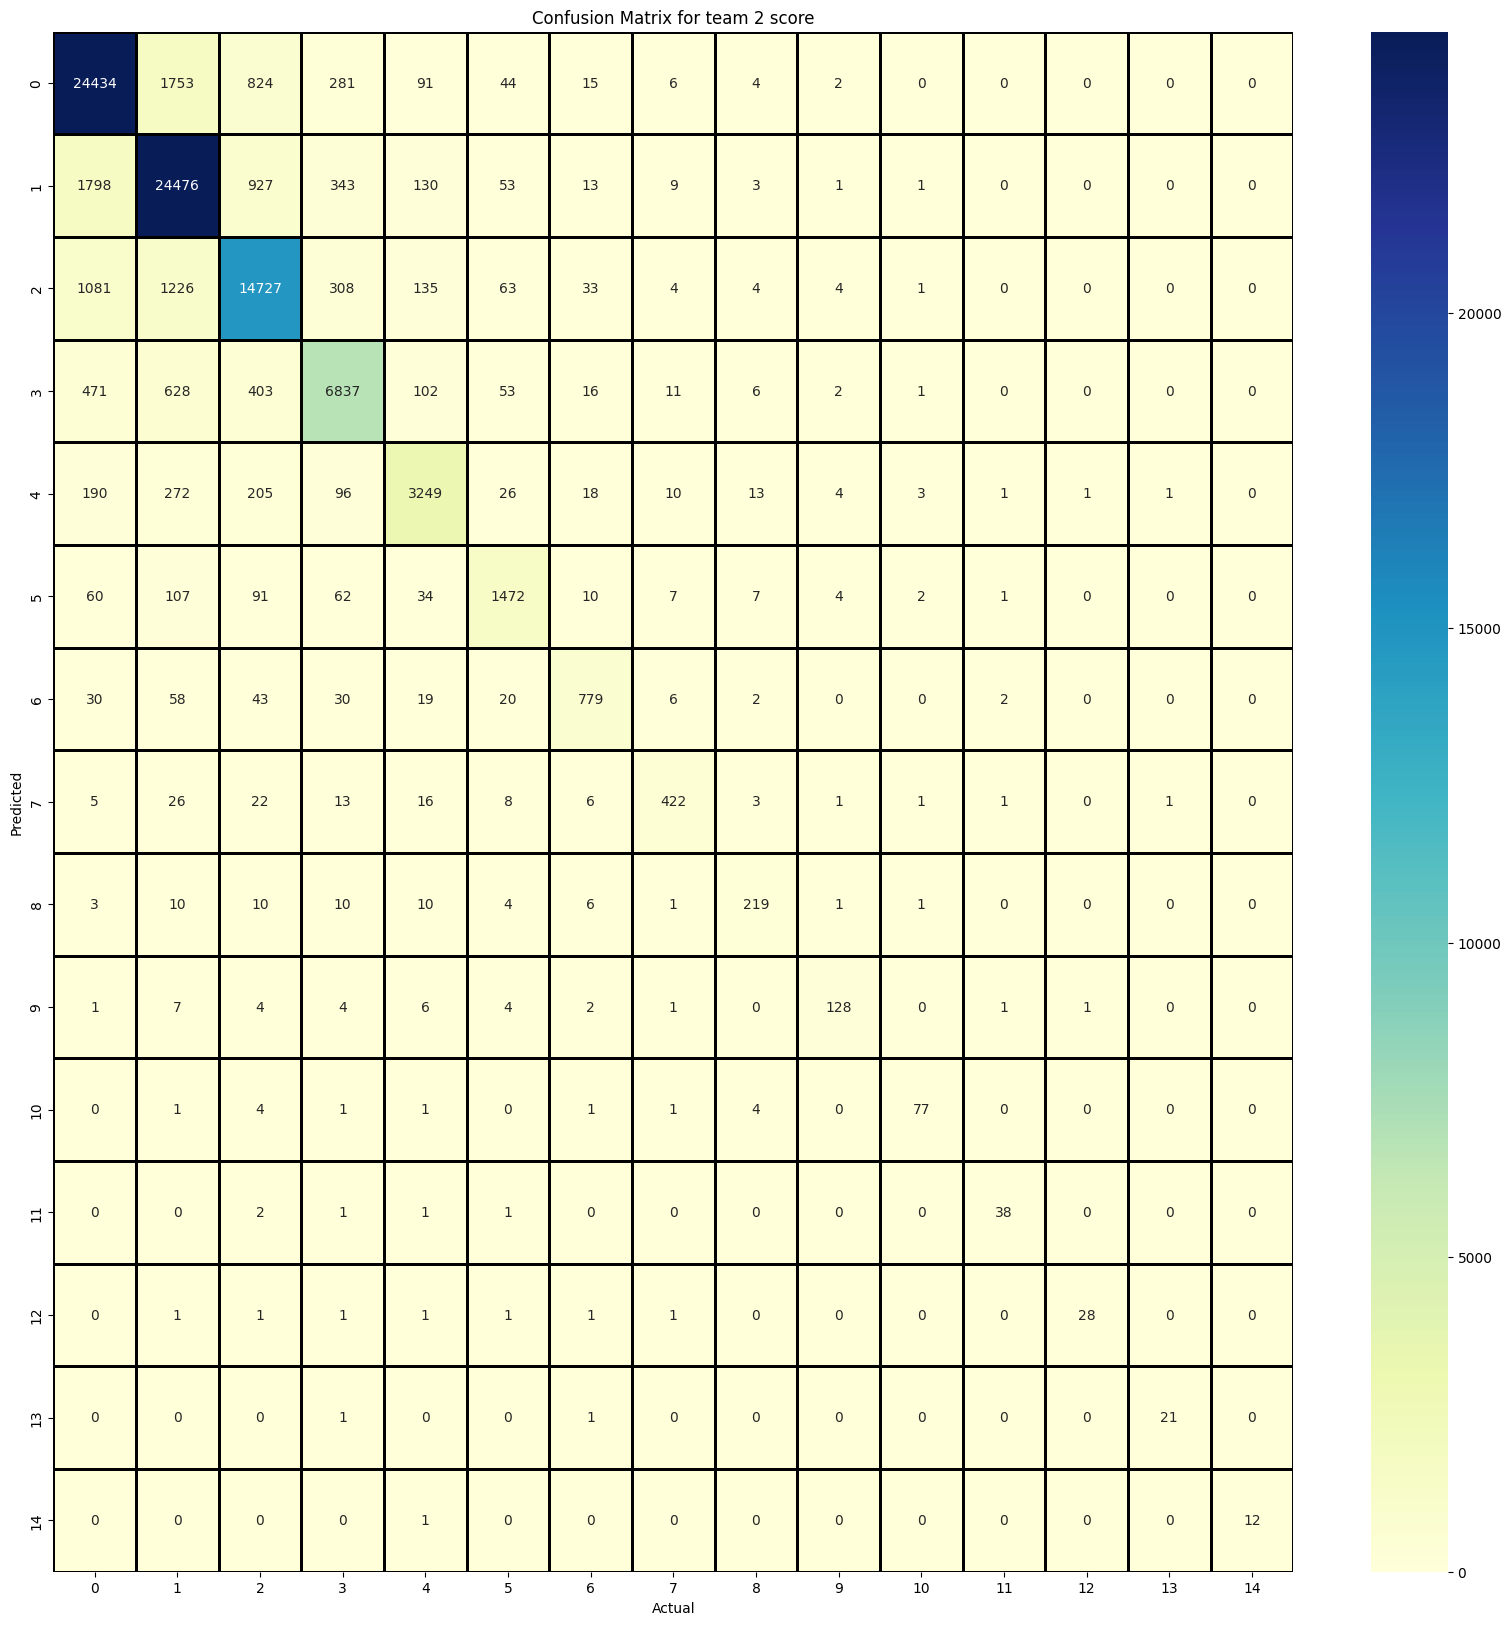

In [172]:
#Plotting the Confussion Matrix for score of team 02

plt.figure(figsize=(20,20))
sns.heatmap(cm2, annot=True,fmt="d", cmap='YlGnBu', linecolor='black', linewidths=1)
plt.title("Confusion Matrix for team 2 score")
plt.xlabel("Actual")
plt.ylabel("Predicted")

To generate a classification report for a classification task

In [173]:
#Classification Report to team 2 Score

report_2=classification_report(Y.iloc[:,1],score_team_2)
print(report_2)

#Has a good Accuracy in predicting the team 1 Score#

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     27454
           1       0.86      0.88      0.87     27754
           2       0.85      0.84      0.85     17586
           3       0.86      0.80      0.83      8530
           4       0.86      0.79      0.82      4089
           5       0.84      0.79      0.82      1857
           6       0.86      0.79      0.82       989
           7       0.88      0.80      0.84       525
           8       0.83      0.80      0.81       275
           9       0.87      0.81      0.84       159
          10       0.89      0.86      0.87        90
          11       0.86      0.88      0.87        43
          12       0.93      0.80      0.86        35
          13       0.91      0.91      0.91        23
          14       1.00      0.92      0.96        13

    accuracy                           0.86     89422
   macro avg       0.88      0.84      0.86     89422
weighted avg       0.86   

his function takes as input a probability array, which presumably contains the predicted probabilities for two teams in a binary classification problem. It then selects the winning team based on these probabilities. Here's how the function works:

In [174]:
#Fuction to Select the winning team for the prediction array


def select_winning_team(probability_array):
    prob_lst=[round(probability_array[0][i],3) for i in range(2)]
    if (prob_lst[0]>prob_lst[1]):
        out=0
    elif (prob_lst[0]<prob_lst[1]):
        out=1
    elif (prob_lst[0]==prob_lst[1]):
        out=2
    return out,prob_lst

In [175]:
#Sample Prediction

mactch_played=2015
team_1="Sri Lanka"
team_2="Brazil"
stadium="Qatar"

team_lst=[team_1,team_2]
team_1_num=label_encoder.transform([team_1])[0]
team_2_num=label_encoder.transform([team_2])[0]
stadium_num=label_encoder.transform([stadium])[0]

print(f"Team 01 is {team_1} -{team_1_num}")
print(f"Team 02 is {team_2} -{team_2_num}")
print(f"Played in  {stadium} -{stadium_num}")

Team 01 is Sri Lanka -285
Team 02 is Brazil -41
Played in  Qatar -241


In [176]:
X_feature=np.array([[mactch_played,stadium_num,team_1_num,team_2_num]])
res=model.predict(X_feature)
win,_=select_winning_team(res)
try:
    print(f"{team_1} vs {team_2} \n {team_lst[win]} wins 🏆⚽🎯\n")
except IndexError:
    print(f"{team_1} vs {team_2} \n  Match Draw ⚽⚽⚽\n")

Sri Lanka vs Brazil 
 Brazil wins 🏆⚽🎯



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**FIFA WORLD CUP - 2022 ⚽️-**

I have selected 32 teams that has the maximum posibility to participate in FIFA World Cup 2022. These teams are selected accordingto the current world ranking and recently helg Euro Cup performances.

Every team plays with evey one-else(League System).That means one team plays 63 matches.Then from the model I predict who is going to win the match.

Winning team gets 02 Point
Match draw (Both teams scored same number of goals)- both teams get 1 points each
Team Lost gets no points
According this points system final winner will be selected